In [ ]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import src

mpl.rc("text", usetex=True)
mpl.rc("font", family="serif")

# Economic sector imputation

A substantial share of workers in the OD survey has no observed economic sector, so the objective of this stage is to estimate

$$P(S=s\mid X),$$

where $S$ denotes one of the four harmonized economic sectors and $X$ contains the available sociodemographic and labor characteristics.

Initially, sector was predicted using models trained on ENOE and transferred to OD, selecting models mainly through balanced accuracy and assigning each worker to the most likely sector,

$$\hat{s}_i=\arg\max_s P(S_i=s\mid X_i).$$

Although this approach showed some individual signal, it transferred poorly between surveys and produced strongly distorted aggregate distributions, particularly by overassigning `gobierno_otro_agricultura` and underassigning `servicios_transporte`. We therefore tested models trained directly on OD workers with observed sector and found that OD-specific predictors, especially the original detailed occupation variable, provided better information than the previously harmonized predictors. We also replaced artificial class balancing and hard-classification-oriented model selection with probability estimation using survey expansion factors and weighted multiclass log loss,

$$\mathcal{L}=-\frac{\sum_i w_i\log P(S_i=s_i\mid X_i)}{\sum_i w_i}.$$

Two specifications were evaluated: one including education and another excluding it, since education is missing for approximately 46.5% of workers whose sector must be imputed. The final procedure therefore uses a hybrid model: $P(S\mid X,\text{education})$ when education is observed and $P(S\mid X)$ when it is unavailable. The four predicted sector probabilities are retained, allowing aggregate sector employment to be estimated as

$$\hat{N}_s=\sum_i w_iP(S_i=s\mid X_i).$$

This probabilistic approach reproduced the held-out OD sector distribution closely and is therefore used for the final economic-sector imputation.

In [ ]:
od = pd.read_parquet("outputs/od_harmonized.parquet")
print(f"OD workers: {len(od):,}")
print(f"Workers with known sector: {(~od['sector_desconocido']).sum():,}")
print(f"Workers with unknown sector: {od['sector_desconocido'].sum():,}")

OD workers: 26,913
Workers with known sector: 17,429
Workers with unknown sector: 9,484


## Sector missingness profiles

We first compare the weighted characteristics of workers with observed and missing economic sector. This allows us to identify systematic differences between the training population and the population for which sector must be imputed.

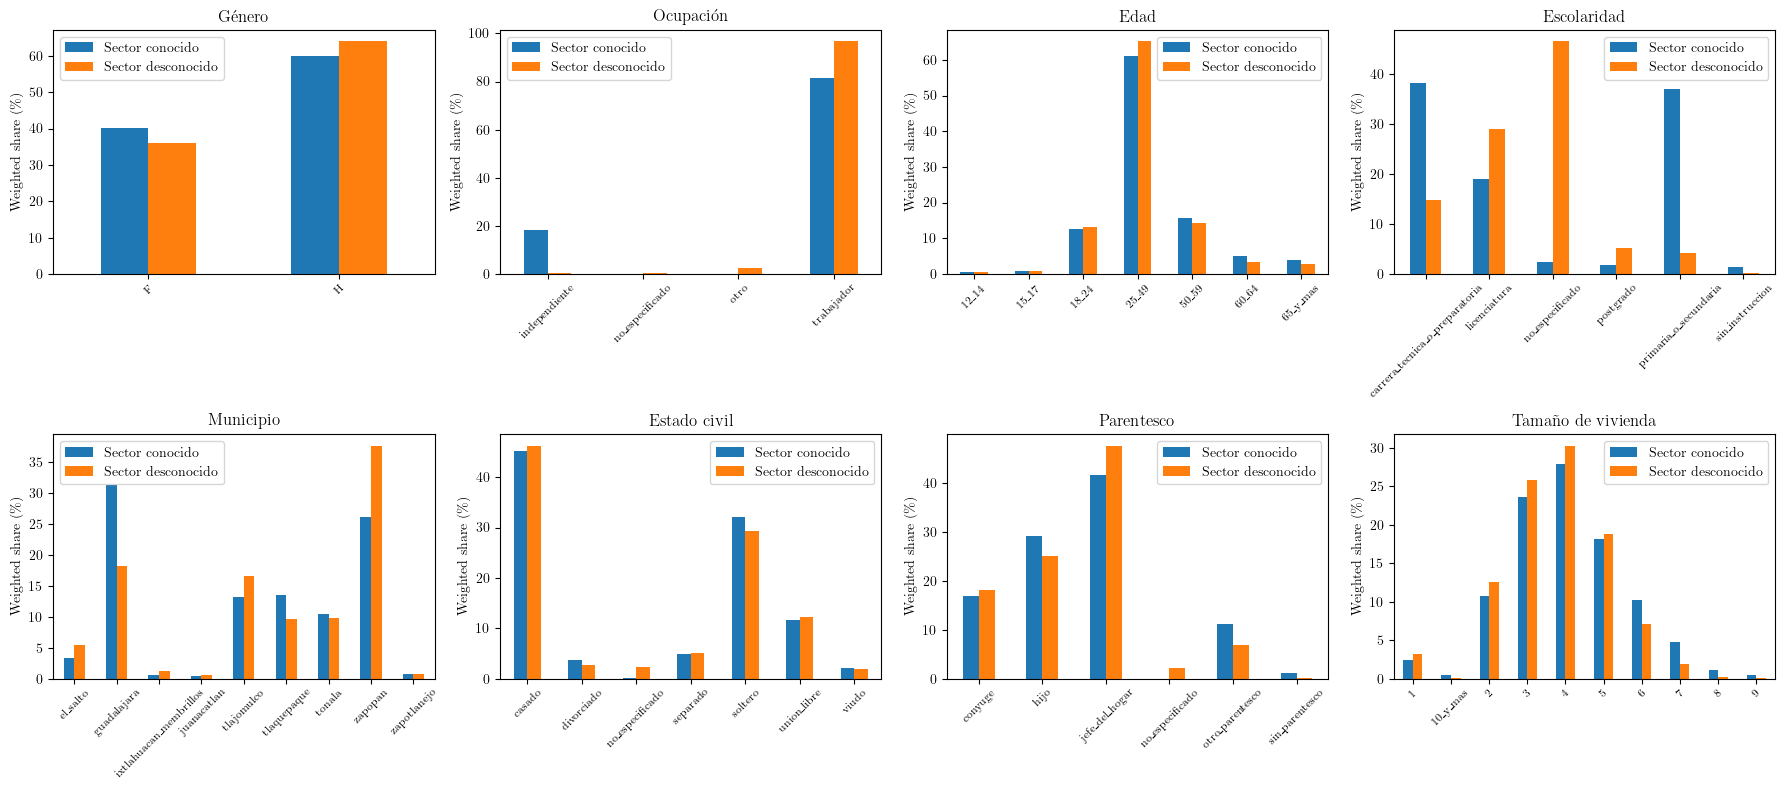

In [ ]:
profile_columns = ["genero", "ocupacion", "edad_cat", "escolaridad", "municipio", "estado_civil", "parentesco", "tamano_viv_cat"]
sector_missingness_profiles = src.compare_sector_known_unknown_profiles(od, profile_columns)
plot_titles = {
    "genero": "Género",
    "ocupacion": "Ocupación",
    "edad_cat": "Edad",
    "escolaridad": "Escolaridad",
    "municipio": "Municipio",
    "estado_civil": "Estado civil",
    "parentesco": "Parentesco",
    "tamano_viv_cat": "Tamaño de vivienda"
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, variable in zip(axes.flatten(), profile_columns):
    plot_data = sector_missingness_profiles[sector_missingness_profiles["variable"] == variable].copy()
    plot_data = plot_data.set_index("category")[["known_share", "unknown_share"]] * 100
    plot_data.plot(kind="bar", ax=ax)
    ax.set_title(plot_titles[variable])
    ax.set_xlabel("")
    ax.set_ylabel("Weighted share (\\%)")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.legend(["Sector conocido", "Sector desconocido"])
plt.tight_layout()
plt.show()

## OD-specific predictors

Because the economic-sector model is now trained and applied within the OD survey, we can use detailed OD variables that did not have direct ENOE equivalents. In particular, the original occupation variable retains considerably more information than the harmonized occupation category.

In [ ]:
with_education_features = src.OD_SECTOR_FEATURES
without_education_features = src.OD_ROBUST_SECTOR_FEATURES
print("With education:")
print(*with_education_features, sep="\n")
print("\nWithout education:")
print(*without_education_features, sep="\n")

With education:
genero
edad_num
escolaridad
municipio
estado_civil
parentesco
tamano_viv_cat
Ocupación:
Durante la semana pasada trabajó:
Centralidad

Without education:
genero
edad_num
municipio
estado_civil
parentesco
tamano_viv_cat
Ocupación:
Durante la semana pasada trabajó:
Centralidad


### Predictor missingness

Missingness is compared between workers with observed and missing sector. The comparison includes both actual missing values and the harmonized `no_especificado` category.

In [5]:
feature_missingness = src.calculate_od_sector_feature_missingness(od, sector_features=with_education_features)
print(feature_missingness)

                            variable  known_missing_share  \
0                             genero             0.000000   
1                           edad_num             0.000000   
2                        escolaridad             0.025019   
3                          municipio             0.000000   
4                       estado_civil             0.001839   
5                         parentesco             0.000000   
6                     tamano_viv_cat             0.000000   
7                         Ocupación:             0.000000   
8  Durante la semana pasada trabajó:             0.000000   
9                        Centralidad             0.000000   

   unknown_missing_share  
0               0.000000  
1               0.000000  
2               0.465404  
3               0.000000  
4               0.024018  
5               0.021755  
6               0.000000  
7               0.002910  
8               0.000000  
9               0.000000  


## Common OD train-test split

Workers with observed sector are divided into a training sample and a held-out test sample. The split is grouped by household to prevent members of the same household from appearing in both training and testing data.

In [ ]:
od_sector_train, od_sector_test = src.split_od_sector_known_data(od, n_splits=5, test_fold=0, random_state=42)
print(f"OD workers available for training: {len(od_sector_train):,}")
print(f"OD workers reserved for testing: {len(od_sector_test):,}")
print(f"Training households: {od_sector_train['Folio Vivienda'].nunique():,}")
print(f"Testing households: {od_sector_test['Folio Vivienda'].nunique():,}")

OD workers available for training: 13,892
OD workers reserved for testing: 3,537
Training households: 8,112
Testing households: 2,051


## Model A: OD-specific predictors with education

Three classifiers are compared using weighted grouped cross-validation. Model selection is based on weighted multiclass log loss. Survey expansion factors are used as sample weights, while no artificial class balancing is applied.

In [ ]:
# Prepare data
X_with_education, y_with_education, weights_with_education, groups_with_education, training_with_education = src.prepare_od_probabilistic_sector_training_data(od_sector_train, sector_features=with_education_features)
print(f"Workers used for training: {len(training_with_education):,}")
print(f"Households used for training: {groups_with_education.nunique():,}")

Workers used for training: 13,892
Households used for training: 8,112


In [8]:
# Tune models
with_education_summary, with_education_models = src.tune_probabilistic_sector_models(X_with_education, y_with_education, weights_with_education, groups_with_education, sector_features=with_education_features, cv_splits=5, random_state=42)
print(with_education_summary)

                model  weighted_log_loss  weighted_log_loss_std  \
0        RandomForest           1.091191               0.022030   
1    GradientBoosting           1.095803               0.021527   
2  LogisticRegression           1.107952               0.025851   

   weighted_balanced_accuracy  weighted_accuracy  weighted_f1_macro  \
0                    0.362971           0.459706           0.353156   
1                    0.361728           0.448620           0.359609   
2                    0.351065           0.444370           0.346343   

                                         best_params  
0  {'classifier__max_features': 0.7, 'classifier_...  
1  {'classifier__l2_regularization': 0.0, 'classi...  
2                             {'classifier__C': 0.1}  


In [ ]:
# Best model
with_education_best_name, with_education_best_model = src.get_best_probabilistic_sector_model(with_education_summary, with_education_models)
print(f"Best model with education: {with_education_best_name}")
print(with_education_summary.loc[with_education_summary["model"] == with_education_best_name, "best_params"].iloc[0])

Best model with education: RandomForest
{'classifier__max_features': 0.7, 'classifier__max_leaf_nodes': 100, 'classifier__min_samples_leaf': 1}


In [ ]:
# Held-out test
with_education_metrics, with_education_class_metrics, with_education_confusion, with_education_distribution = src.evaluate_probabilistic_sector_model(with_education_best_model, od_sector_test, sector_features=with_education_features)
print(with_education_metrics.round(4))
print(with_education_class_metrics.round(4))
print(with_education_distribution.round(4))

   accuracy  balanced_accuracy  f1_macro  weighted_accuracy  \
0    0.4603             0.3632    0.3586             0.4651   

   weighted_balanced_accuracy  weighted_f1_macro  weighted_log_loss  
0                      0.3685             0.3649             1.0898  
                      sector  precision  recall      f1  weighted_support
0                   comercio     0.5186  0.4616  0.4884          111895.0
1  gobierno_otro_agricultura     0.5195  0.0221  0.0424           11445.0
2   manufactura_construccion     0.4127  0.5126  0.4573           83027.0
3       servicios_transporte     0.4655  0.4779  0.4716          119537.0
                      sector  observed_population  observed_share  \
0                   comercio               111895          0.3433   
1  gobierno_otro_agricultura                11445          0.0351   
2   manufactura_construccion                83027          0.2548   
3       servicios_transporte               119537          0.3668   

   hard_predicted

## Model B: OD-specific predictors without education

Because education is missing much more frequently among workers whose sector must be imputed, a second model excludes education while retaining detailed OD occupation and the remaining OD-specific predictors.

In [ ]:
# Prepare data
X_without_education, y_without_education, weights_without_education, groups_without_education, training_without_education = src.prepare_od_probabilistic_sector_training_data(od_sector_train, sector_features=without_education_features)
print(f"Workers used for training: {len(training_without_education):,}")
print(f"Households used for training: {groups_without_education.nunique():,}")

Workers used for training: 13,892
Households used for training: 8,112


In [ ]:
# Tune models
without_education_summary, without_education_models = src.tune_probabilistic_sector_models(X_without_education, y_without_education, weights_without_education, groups_without_education, sector_features=without_education_features, cv_splits=5, random_state=42)
print(without_education_summary)

                model  weighted_log_loss  weighted_log_loss_std  \
0        RandomForest           1.127008               0.020657   
1    GradientBoosting           1.136672               0.022567   
2  LogisticRegression           1.140310               0.026007   

   weighted_balanced_accuracy  weighted_accuracy  weighted_f1_macro  \
0                    0.349792           0.445513           0.340297   
1                    0.343476           0.435154           0.336045   
2                    0.340608           0.433525           0.332411   

                                         best_params  
0  {'classifier__max_features': 0.7, 'classifier_...  
1  {'classifier__l2_regularization': 1.0, 'classi...  
2                             {'classifier__C': 0.1}  


In [ ]:
# Best model
without_education_best_name, without_education_best_model = src.get_best_probabilistic_sector_model(without_education_summary, without_education_models)
print(f"Best model without education: {without_education_best_name}")
print(without_education_summary.loc[without_education_summary["model"] == without_education_best_name, "best_params"].iloc[0])

Best model without education: RandomForest
{'classifier__max_features': 0.7, 'classifier__max_leaf_nodes': 100, 'classifier__min_samples_leaf': 1}


In [ ]:
# Held-out test
without_education_metrics, without_education_class_metrics, without_education_confusion, without_education_distribution = src.evaluate_probabilistic_sector_model(without_education_best_model, od_sector_test, sector_features=without_education_features)
print(without_education_metrics.round(4))
print(without_education_class_metrics.round(4))
print(without_education_distribution.round(4))

   accuracy  balanced_accuracy  f1_macro  weighted_accuracy  \
0    0.4507             0.3503    0.3416             0.4505   

   weighted_balanced_accuracy  weighted_f1_macro  weighted_log_loss  
0                      0.3504             0.3418             1.1149  
                      sector  precision  recall      f1  weighted_support
0                   comercio     0.5334  0.3811  0.4446          111895.0
1  gobierno_otro_agricultura     0.0000  0.0000  0.0000           11445.0
2   manufactura_construccion     0.4072  0.4878  0.4439           83027.0
3       servicios_transporte     0.4346  0.5326  0.4787          119537.0
                      sector  observed_population  observed_share  \
0                   comercio               111895          0.3433   
1  gobierno_otro_agricultura                11445          0.0351   
2   manufactura_construccion                83027          0.2548   
3       servicios_transporte               119537          0.3668   

   hard_predicted

## Model comparison

The two feature specifications are evaluated on exactly the same held-out OD workers. Weighted log loss is the primary metric because the goal is to obtain informative sector probabilities rather than only hard classifications.

In [ ]:
model_comparison = pd.concat([with_education_metrics.assign(features="Con escolaridad"), without_education_metrics.assign(features="Sin escolaridad")], ignore_index=True)
print(model_comparison.round(4))

   accuracy  balanced_accuracy  f1_macro  weighted_accuracy  \
0    0.4603             0.3632    0.3586             0.4651   
1    0.4507             0.3503    0.3416             0.4505   

   weighted_balanced_accuracy  weighted_f1_macro  weighted_log_loss  \
0                      0.3685             0.3649             1.0898   
1                      0.3504             0.3418             1.1149   

          features  
0  Con escolaridad  
1  Sin escolaridad  


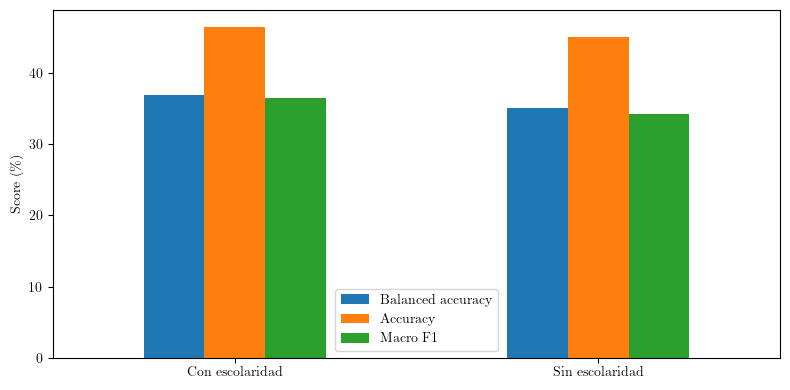

In [ ]:
plot_data = model_comparison.set_index("features")[["weighted_balanced_accuracy", "weighted_accuracy", "weighted_f1_macro"]] * 100
ax = plot_data.plot(kind="bar", figsize=(8, 4))
ax.set_xlabel("")
ax.set_ylabel("Score (\\%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Balanced accuracy", "Accuracy", "Macro F1"])
plt.tight_layout()
plt.show()

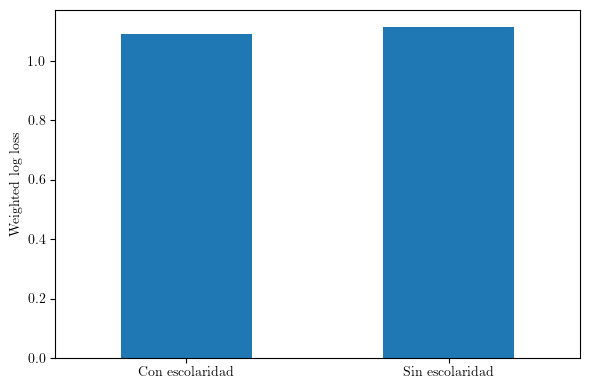

In [ ]:
plot_data = model_comparison.set_index("features")["weighted_log_loss"]
ax = plot_data.plot(kind="bar", figsize=(6, 4))
ax.set_xlabel("")
ax.set_ylabel("Weighted log loss")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
class_comparison = pd.concat([with_education_class_metrics.assign(features="Con escolaridad"), without_education_class_metrics.assign(features="Sin escolaridad")], ignore_index=True)
print(class_comparison.round(4))

                      sector  precision  recall      f1  weighted_support  \
0                   comercio     0.5186  0.4616  0.4884          111895.0   
1  gobierno_otro_agricultura     0.5195  0.0221  0.0424           11445.0   
2   manufactura_construccion     0.4127  0.5126  0.4573           83027.0   
3       servicios_transporte     0.4655  0.4779  0.4716          119537.0   
4                   comercio     0.5334  0.3811  0.4446          111895.0   
5  gobierno_otro_agricultura     0.0000  0.0000  0.0000           11445.0   
6   manufactura_construccion     0.4072  0.4878  0.4439           83027.0   
7       servicios_transporte     0.4346  0.5326  0.4787          119537.0   

          features  
0  Con escolaridad  
1  Con escolaridad  
2  Con escolaridad  
3  Con escolaridad  
4  Sin escolaridad  
5  Sin escolaridad  
6  Sin escolaridad  
7  Sin escolaridad  


In [19]:
distribution_comparison = with_education_distribution[["sector", "observed_share", "hard_predicted_share", "probabilistic_predicted_share"]].copy()

distribution_comparison = distribution_comparison.rename(columns={
    "hard_predicted_share": "hard_with_education",
    "probabilistic_predicted_share": "probabilistic_with_education"
})

distribution_comparison = distribution_comparison.merge(without_education_distribution[["sector", "hard_predicted_share", "probabilistic_predicted_share"]].rename(columns={
    "hard_predicted_share": "hard_without_education",
    "probabilistic_predicted_share": "probabilistic_without_education"
}), on="sector", how="left")

print(distribution_comparison.round(4))

                      sector  observed_share  hard_with_education  \
0                   comercio          0.3433               0.3056   
1  gobierno_otro_agricultura          0.0351               0.0015   
2   manufactura_construccion          0.2548               0.3164   
3       servicios_transporte          0.3668               0.3765   

   probabilistic_with_education  hard_without_education  \
0                        0.3293                  0.2453   
1                        0.0422                  0.0000   
2                        0.2638                  0.3052   
3                        0.3647                  0.4495   

   probabilistic_without_education  
0                           0.3287  
1                           0.0420  
2                           0.2633  
3                           0.3659  


## Hybrid sector model

The model including education obtains the lowest weighted log loss and the best overall predictive performance. However, education is unavailable for a substantial fraction of workers whose economic sector must be imputed.

Therefore, the final imputation uses a hybrid strategy. Workers with observed education are evaluated with the model including education, while workers with missing or unspecified education are evaluated with the model excluding education. Both models are refitted using all OD workers with observed economic sector.

Sector probabilities are retained for all imputed workers. Hard sector assignments correspond to the maximum predicted probability and are preserved mainly for compatibility with subsequent individual-level analyses.

In [ ]:
# Refit both models using all workers with observed sector
final_with_education_model, final_with_education_training = src.refit_probabilistic_sector_model(with_education_best_model, od, sector_features=with_education_features)
final_without_education_model, final_without_education_training = src.refit_probabilistic_sector_model(without_education_best_model, od, sector_features=without_education_features)
print(f"Workers used for final training: {len(final_with_education_training):,}")
print(f"Households used for final training: {final_with_education_training['Folio Vivienda'].nunique():,}")

Workers used for final training: 17,429
Households used for final training: 10,163


In [ ]:
# Hybrid sector imputation
od_sector_imputed = src.impute_missing_sectors_hybrid(final_with_education_model, final_without_education_model, od, with_education_features=with_education_features, without_education_features=without_education_features)
print(f"Workers with observed sector: {(~od_sector_imputed['sector_fue_imputado']).sum():,}")
print(f"Workers with imputed sector: {od_sector_imputed['sector_fue_imputado'].sum():,}")
print(f"Workers without final sector: {od_sector_imputed['sector_final'].isna().sum():,}")

Workers with observed sector: 17,429
Workers with imputed sector: 9,484
Workers without final sector: 0


In [23]:
model_usage = src.calculate_sector_model_usage(od_sector_imputed)
print(model_usage)

   sector_model_used  sample_workers  weighted_population  sample_share  \
0     with_education            4962               366704      0.523197   
1  without_education            4522               319242      0.476803   

   weighted_share  
0        0.534596  
1        0.465404  


In [ ]:
maximum_probability_error = src.validate_sector_probability_rows(od_sector_imputed)
print(f"Maximum probability-sum error: {maximum_probability_error:.3e}")

Maximum probability-sum error: 2.220e-16


In [25]:
imputed_workers = od_sector_imputed[od_sector_imputed["sector_fue_imputado"]].copy()

In [ ]:
hard_imputed_distribution = src.calculate_sector_distribution(imputed_workers, sector_column="sector_final")
print("Hard imputed distribution")
print(hard_imputed_distribution)

Hard imputed distribution
                sector_final  weighted_population  weighted_share
0                   comercio               101653        0.148194
1  gobierno_otro_agricultura                  399        0.000582
2   manufactura_construccion               197558        0.288008
3       servicios_transporte               386336        0.563216


In [ ]:
probabilistic_imputed_distribution = src.calculate_probabilistic_sector_distribution(imputed_workers)
print("Probabilistic imputed distribution")
print(probabilistic_imputed_distribution)

Probabilistic imputed distribution
                      sector  weighted_population  weighted_share
0                   comercio        172691.124651        0.251756
1  gobierno_otro_agricultura         58310.577724        0.085008
2   manufactura_construccion        202816.821137        0.295675
3       servicios_transporte        252127.476487        0.367562


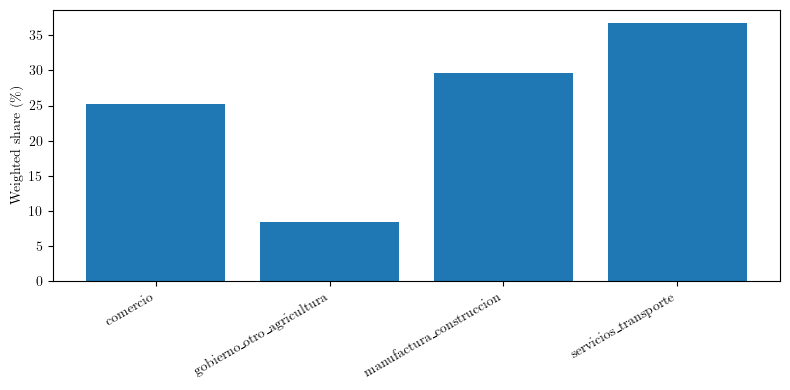

In [ ]:
plot_data = probabilistic_imputed_distribution.copy()
plot_data["weighted_share"] *= 100
plt.figure(figsize=(8, 4))
plt.bar(plot_data["sector"], plot_data["weighted_share"])
plt.xlabel("")
plt.ylabel("Weighted share (\\%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
confidence_summary = src.calculate_sector_confidence_summary(od_sector_imputed)
print(confidence_summary.round(4))

   sector_model_used  count    mean     std     min  median     max
0     with_education   4962  0.4152  0.0736  0.2734  0.3934  0.9492
1  without_education   4522  0.3953  0.0466  0.3131  0.3844  0.9485


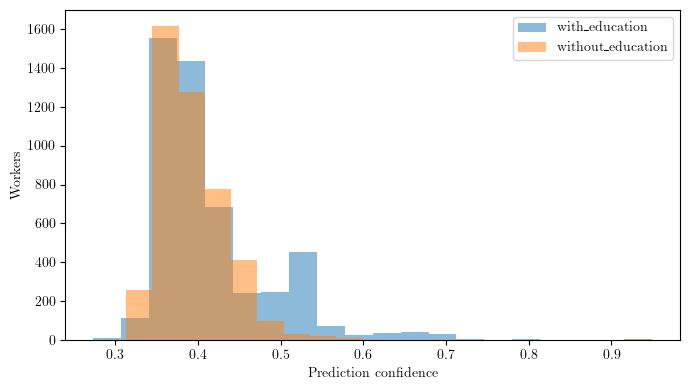

In [30]:
plt.figure(figsize=(7, 4))

for model_name, group in imputed_workers.groupby("sector_model_used"):
    plt.hist(group["sector_prediction_confidence"], bins=20, alpha=0.5, label=model_name)

plt.xlabel("Prediction confidence")
plt.ylabel("Workers")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
hard_final_distribution = src.calculate_sector_distribution(od_sector_imputed, sector_column="sector_final")
print("Hard final distribution")
print(hard_final_distribution)

Hard final distribution
                sector_final  weighted_population  weighted_share
0                   comercio               630902         0.27764
1  gobierno_otro_agricultura                64708        0.028476
2   manufactura_construccion               612627        0.269597
3       servicios_transporte               964141        0.424287


In [ ]:
probabilistic_final_distribution = src.calculate_probabilistic_sector_distribution(od_sector_imputed)
print("Probabilistic final distribution")
print(probabilistic_final_distribution)

Probabilistic final distribution
                      sector  weighted_population  weighted_share
0                   comercio        701940.124651        0.308901
1  gobierno_otro_agricultura        122619.577724        0.053961
2   manufactura_construccion        617885.821137        0.271912
3       servicios_transporte        829932.476487        0.365226


In [ ]:
observed_distribution = src.calculate_sector_distribution(od[~od["sector_desconocido"]], sector_column="sector")
observed_comparison = observed_distribution[["sector", "weighted_share"]].rename(columns={"weighted_share": "observed_known_share"})
observed_comparison = observed_comparison.merge(probabilistic_imputed_distribution[["sector", "weighted_share"]].rename(columns={"weighted_share": "imputed_share"}), on="sector", how="outer")
observed_comparison = observed_comparison.merge(probabilistic_final_distribution[["sector", "weighted_share"]].rename(columns={"weighted_share": "final_share"}), on="sector", how="outer")
print(observed_comparison.round(4))

                      sector  observed_known_share  imputed_share  final_share
0                   comercio                0.3336         0.2518       0.3089
1  gobierno_otro_agricultura                0.0405         0.0850       0.0540
2   manufactura_construccion                0.2616         0.2957       0.2719
3       servicios_transporte                0.3642         0.3676       0.3652


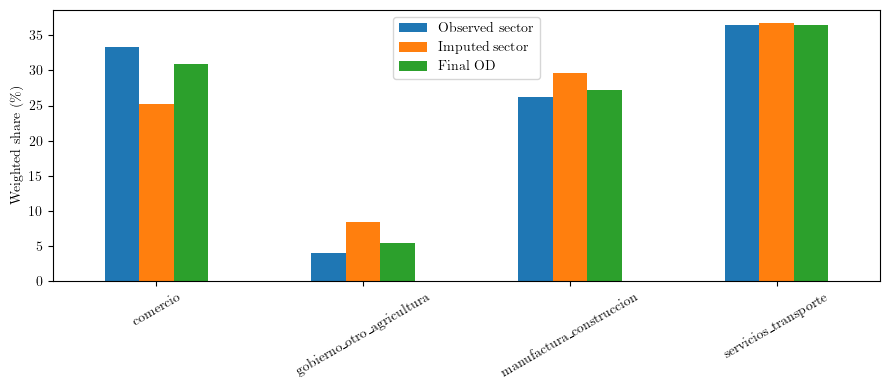

In [34]:
plot_data = observed_comparison.set_index("sector")[["observed_known_share", "imputed_share", "final_share"]] * 100

ax = plot_data.plot(kind="bar", figsize=(9, 4))
ax.set_xlabel("")
ax.set_ylabel("Weighted share (\\%)")
ax.tick_params(axis="x", rotation=30)
ax.legend(["Observed sector", "Imputed sector", "Final OD"])

plt.tight_layout()
plt.show()

In [35]:
output_directory = Path("outputs")
output_directory.mkdir(exist_ok=True)

output_path = output_directory / "od_sector_imputed.parquet"
od_sector_imputed.to_parquet(output_path, index=False)

In [36]:
from joblib import dump

models_directory = Path("outputs/models")
models_directory.mkdir(parents=True, exist_ok=True)

sector_model_bundle = {
    "model_with_education": final_with_education_model,
    "model_without_education": final_without_education_model,
    "features_with_education": with_education_features,
    "features_without_education": without_education_features
}

model_path = models_directory / "economic_sector_hybrid_model.joblib"
dump(sector_model_bundle, model_path)

print(f"Saved: {model_path}")

Saved: outputs/models/economic_sector_hybrid_model.joblib
